<a href="https://colab.research.google.com/github/fabriciosantana/mcdia/blob/main/09-appd/assignments/04-did-bolsa-familia-evasao/atividade_did_bolsa_familia_evasao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Instituto Brasileiro de Ensino, Desenvolvimento e Pesquisa**

Programa de Pós-Graduação em Administração Pública — Mestrado Profissional

**Disciplina:** Avaliação de Políticas Públicas com Dados  
**Atividade:** Seleção nos observáveis, pareamento e escore de propensão  
**Grupo:** Analécia Borato, Fabricio Santana, Giovanni Brígido, Paulo Ceser

# Efeito do Bolsa Familia sobre a evasao escolar: diferencas em diferencas

## Pergunta e desenho

Qual foi o efeito do Bolsa Familia sobre a evasao escolar media dos domicilios
entre 2005 e 2009? O desfecho e `dropout_med`, diferente de `attend_med`, usado
como exemplo principal em aula.

- **Unidade:** domicilio (`cod_dtm`).
- **Periodo pre:** 2005; **periodo pos:** 2009.
- **Comparacao principal:** beneficiarios em 2009 (`T1`) versus inscritos no
  Cadastro Unico que nao recebiam o beneficio (`C1`).
- **Placebo:** `C1` versus nao inscritos (`C2`), tratando artificialmente `C1`.
- **Estimando:** DiD medio na amostra de domicilios observados nas duas rodadas.

Sao estimadas duas especificacoes: regressao canonica com a interacao
tratado x pos e TWFE com efeitos fixos de domicilio e ano. Os erros-padrao sao
agrupados por domicilio.

In [5]:
%pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 11.2 MB/s eta 0:00:00


In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

In [17]:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    caminho = Path("/content/drive/MyDrive/Colab Notebooks/data/aula04_painel.csv")
except ImportError:
    print('Execução local detectada; o Google Drive não será montado.')
    caminho = Path("./data/aula04_painel.csv")

if caminho is None:
    raise FileNotFoundError("Nao foi possivel localizar aula04_painel.csv")
else:
    print(f"Arquivo encontrado em {caminho}")

Mounted at /content/drive
Arquivo encontrado em /content/drive/MyDrive/Colab Notebooks/data/aula04_painel.csv


## 1. Dados e recorte analitico

A base e o painel domiciliar da AIBF II preparado para o Modulo 04. Para cada
comparacao, mantemos apenas valores observados de `dropout_med` e domicilios
presentes em 2005 e 2009. Essa decisao evita que diferencas entre a regressao
canonica e o TWFE sejam produzidas apenas por amostras distintas.

In [18]:
aibf = pd.read_csv(caminho)
necessarias = {"cod_dtm", "ano", "grupo", "pos", "dropout_med"}
assert necessarias.issubset(aibf.columns)
assert set(aibf["ano"].unique()) == {2005, 2009}
assert not aibf.duplicated(["cod_dtm", "ano"]).any()
print(f"Base: {len(aibf):,} linhas e {aibf['cod_dtm'].nunique():,} domicilios")

Base: 19,425 linhas e 12,594 domicilios


In [19]:
def preparar_painel(base, grupos, grupo_tratado):
    d = base.loc[base["grupo"].isin(grupos)].dropna(subset=["dropout_med"]).copy()
    d["tratamento"] = (d["grupo"] == grupo_tratado).astype(int)
    rodadas = d.groupby("cod_dtm")["ano"].nunique()
    completos = rodadas[rodadas == 2].index
    d = d[d["cod_dtm"].isin(completos)].copy()
    d["D"] = d["tratamento"] * d["pos"]
    assert d.groupby("cod_dtm")["ano"].nunique().eq(2).all()
    assert d.groupby("cod_dtm")["tratamento"].nunique().eq(1).all()
    return d


principal = preparar_painel(aibf, ["T1", "C1"], "T1")
placebo = preparar_painel(aibf, ["C1", "C2"], "C1")

pd.DataFrame([
    {"comparacao": "T1 x C1", "linhas": len(principal),
     "domicilios": principal.cod_dtm.nunique()},
    {"comparacao": "C1 x C2 (placebo)", "linhas": len(placebo),
     "domicilios": placebo.cod_dtm.nunique()},
])

,comparacao,linhas,domicilios
0,T1 x C1,6402,3201
1,C1 x C2 (placebo),8202,4101


## 2. Tabela 2 x 2 e estimativa manual

O estimador e

$$
\widehat{DiD}=(\bar Y_{T,pos}-\bar Y_{T,pre})
              -(\bar Y_{C,pos}-\bar Y_{C,pre}).
$$

Como evasao e um desfecho desfavoravel, coeficientes negativos sao compativeis
com um efeito benefico do programa.

In [20]:
def tabela_2x2(d):
    tab = d.groupby(["tratamento", "ano"])["dropout_med"].mean().unstack()
    tab.index = ["controle", "tratado"]
    tab.columns = ["2005 (pre)", "2009 (pos)"]
    tab["variacao"] = tab["2009 (pos)"] - tab["2005 (pre)"]
    did = tab.loc["tratado", "variacao"] - tab.loc["controle", "variacao"]
    return tab, did


tab_principal, did_principal = tabela_2x2(principal)
display(tab_principal)
print(f"DiD manual T1 x C1: {did_principal:+.4f} ({100*did_principal:+.2f} p.p.)")

,2005 (pre),2009 (pos),variacao
controle,0.0295,0.0873,0.0578
tratado,0.0231,0.0753,0.0522


DiD manual T1 x C1: -0.0056 (-0.56 p.p.)


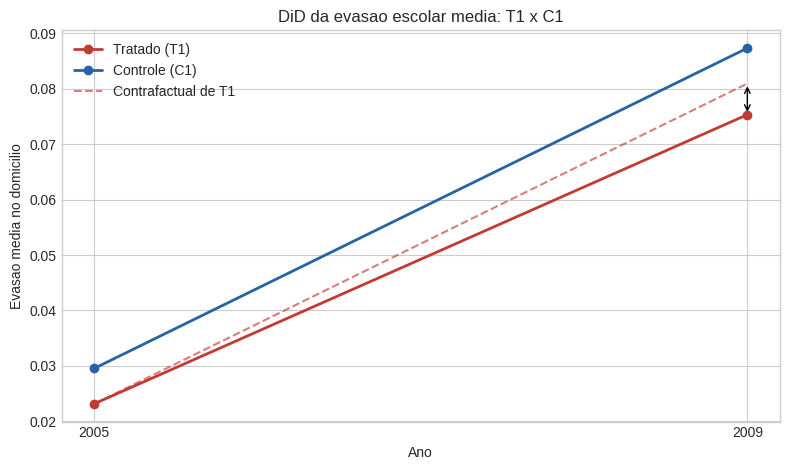

In [21]:
medias = principal.groupby(["ano", "grupo"])["dropout_med"].mean().unstack()
contrafactual = medias.loc[2005, "T1"] + (medias.loc[2009, "C1"] - medias.loc[2005, "C1"])

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(medias.index, medias["T1"], "o-", lw=2, label="Tratado (T1)", color="#C23B33")
ax.plot(medias.index, medias["C1"], "o-", lw=2, label="Controle (C1)", color="#2563A6")
ax.plot([2005, 2009], [medias.loc[2005, "T1"], contrafactual], "--",
        color="#C23B33", alpha=.65, label="Contrafactual de T1")
ax.annotate("", xy=(2009, medias.loc[2009, "T1"]), xytext=(2009, contrafactual),
            arrowprops={"arrowstyle": "<->", "color": "black"})
ax.set(title="DiD da evasao escolar media: T1 x C1", xlabel="Ano",
       ylabel="Evasao media no domicilio", xticks=[2005, 2009])
ax.legend()
plt.tight_layout()

## 3. Especificacao 1: regressao com interacao

$$
Y_{it}=\alpha+\beta Tratado_i+\gamma Pos_t
       +\delta(Tratado_i\times Pos_t)+\varepsilon_{it}.
$$

O coeficiente $\delta$ e a DiD. A inferencia permite dependencia arbitraria
entre as duas observacoes do mesmo domicilio.

In [22]:
def estimar_interacao(d):
    return smf.ols(
        "dropout_med ~ tratamento + pos + tratamento:pos", data=d
    ).fit(cov_type="cluster", cov_kwds={"groups": d["cod_dtm"].values})


ols_principal = estimar_interacao(principal)
display(ols_principal.summary().tables[1])

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,0.0295,0.004,7.402,0.000,0.022,0.037
tratamento,-0.0064,0.005,-1.326,0.185,-0.016,0.003
pos,0.0578,0.008,7.094,0.000,0.042,0.074
tratamento:pos,-0.0056,0.010,-0.563,0.573,-0.025,0.014


## 4. Especificacao 2: TWFE

$$
Y_{it}=\alpha_i+\gamma_t+\delta D_{it}+\varepsilon_{it},
$$

em que $\alpha_i$ absorve caracteristicas do domicilio constantes no tempo,
$\gamma_t$ absorve choques comuns do ano e $D_{it}=Tratado_i\times Pos_t$.

Em um painel 2 x 2 balanceado, o coeficiente deve coincidir com o da interacao.
No `PanelOLS`, `count_effects=False` evita contar efeitos fixos absorvidos no
ajuste de graus de liberdade quando a covariancia ja e agrupada pela entidade;
assim, a correcao de pequena amostra fica comparavel a da regressao anterior.

In [23]:
def estimar_twfe(d):
    painel = d.set_index(["cod_dtm", "ano"])
    modelo = PanelOLS(painel["dropout_med"], painel[["D"]],
                      entity_effects=True, time_effects=True)
    return modelo.fit(cov_type="clustered", cluster_entity=True,
                      auto_df=False, count_effects=False)


twfe_principal = estimar_twfe(principal)
twfe_principal

Dep. Variable:,dropout_med,R-squared:,0.0001
Estimator:,PanelOLS,R-squared (Between):,-0.0079
No. Observations:,6402,R-squared (Within):,-0.0051
Date:,"Fri, Sep 04 2026",R-squared (Overall):,-0.0066
Time:,16:48:28,Log-likelihood,3784.2
Cov. Estimator:,Clustered,,
,,F-statistic:,0.3345
Entities:,3201,P-value,0.5630
Avg Obs:,2.0000,Distribution:,"F(1,3199)"
Min Obs:,2.0000,,
Max Obs:,2.0000,F-statistic (robust):,0.3175


## 5. Placebo C1 x C2

Repetimos as duas especificacoes entre dois grupos que nao receberam o
tratamento, atribuindo artificialmente o status tratado a `C1`. Um efeito
placebo grande ou preciso sugeriria trajetorias diferenciadas entre os grupos
mesmo sem Bolsa Familia e enfraqueceria o desenho. Resultado proximo de zero e
impreciso e tranquilizador, mas nao demonstra que T1 e C1 teriam tendencias
paralelas sem o programa.

In [24]:
tab_placebo, did_placebo = tabela_2x2(placebo)
ols_placebo = estimar_interacao(placebo)
twfe_placebo = estimar_twfe(placebo)
display(tab_placebo)
print(f"DiD manual C1 x C2: {did_placebo:+.4f} ({100*did_placebo:+.2f} p.p.)")

,2005 (pre),2009 (pos),variacao
controle,0.0227,0.0849,0.0622
tratado,0.0295,0.0873,0.0578


DiD manual C1 x C2: -0.0043 (-0.43 p.p.)


In [26]:
def linha_resultado(comparacao, especificacao, coef, ep, pvalor, intervalo, n_dom):
    return {
        "comparacao": comparacao, "especificacao": especificacao,
        "efeito": coef, "efeito_pp": 100 * coef, "EP": ep,
        "IC95_inf": intervalo.iloc[0], "IC95_sup": intervalo.iloc[1],
        "p_valor": pvalor, "domicilios": n_dom,
    }


resultados = pd.DataFrame([
    linha_resultado("T1 x C1", "Interacao", ols_principal.params["tratamento:pos"],
                    ols_principal.bse["tratamento:pos"], ols_principal.pvalues["tratamento:pos"],
                    ols_principal.conf_int().loc["tratamento:pos"], principal.cod_dtm.nunique()),
    linha_resultado("T1 x C1", "TWFE", twfe_principal.params["D"],
                    twfe_principal.std_errors["D"], twfe_principal.pvalues["D"],
                    twfe_principal.conf_int().loc["D"], principal.cod_dtm.nunique()),
    linha_resultado("C1 x C2 (placebo)", "Interacao", ols_placebo.params["tratamento:pos"],
                    ols_placebo.bse["tratamento:pos"], ols_placebo.pvalues["tratamento:pos"],
                    ols_placebo.conf_int().loc["tratamento:pos"], placebo.cod_dtm.nunique()),
    linha_resultado("C1 x C2 (placebo)", "TWFE", twfe_placebo.params["D"],
                    twfe_placebo.std_errors["D"], twfe_placebo.pvalues["D"],
                    twfe_placebo.conf_int().loc["D"], placebo.cod_dtm.nunique()),
])
display(resultados.round(4))

assert np.isclose(did_principal, ols_principal.params["tratamento:pos"])
assert np.isclose(ols_principal.params["tratamento:pos"], twfe_principal.params["D"])
assert np.isclose(did_placebo, ols_placebo.params["tratamento:pos"])
assert np.isclose(ols_placebo.params["tratamento:pos"], twfe_placebo.params["D"])

,comparacao,especificacao,efeito,efeito_pp,EP,IC95_inf,IC95_sup,p_valor,domicilios
0,T1 x C1,Interacao,-0.0056,-0.5623,0.0100,-0.0252,0.0139,0.5732,3201
1,T1 x C1,TWFE,-0.0056,-0.5623,0.0100,-0.0252,0.0139,0.5731,3201
2,C1 x C2 (placebo),Interacao,-0.0043,-0.4345,0.0096,-0.0232,0.0145,0.6521,4101
3,C1 x C2 (placebo),TWFE,-0.0043,-0.4345,0.0096,-0.0232,0.0145,0.6521,4101


## 6. Interpretacao

Na comparacao principal, a evasao media aumentou de **2,32% para 7,53%** em
T1 (+5,22 p.p.) e de **2,95% para 8,73%** em C1 (+5,78 p.p.). A diferenca das
variacoes foi **-0,56 p.p.**: sob tendencias paralelas, o Bolsa Familia esta
associado a um aumento da evasao 0,56 ponto percentual menor entre os
beneficiarios. Interacao e TWFE entregam o mesmo coeficiente porque usam o
mesmo painel 2 x 2 balanceado.

O intervalo de 95% da especificacao com interacao e aproximadamente
**[-2,52; 1,39] p.p.** (`p=0,573`). Portanto, a direcao e favoravel, mas a
estimativa e imprecisa e compativel tanto com uma reducao modesta quanto com
efeito nulo ou pequeno aumento. Nao se rejeitar a hipotese nula nao prova
ausencia de efeito.

No placebo, a evasao cresceu 5,78 p.p. em C1 e 6,22 p.p. em C2. A DiD foi
**-0,43 p.p.**, tambem proxima de zero e imprecisa (IC95% da interacao de
aproximadamente **[-2,32; 1,45] p.p.**; `p=0,652`). O placebo nao revela uma
mudanca diferencial estatisticamente detectavel entre os controles. Isso e
coerente com o desenho principal, mas nao valida sozinho tendencias paralelas
entre T1 e C1.

### Limites

- Existem apenas um periodo pre e um pos; nao e possivel inspecionar
  pre-tendencias.
- A leitura causal exige tendencias paralelas, ausencia de antecipacao,
  transbordamentos e choques simultaneos especificos de grupo.
- `dropout_med` e uma media domiciliar e sua disponibilidade depende da
  composicao etaria/escolar observada; restringir ao painel completo muda a
  populacao-alvo e pode gerar selecao por atrito.
- T1, C1 e C2 nao foram sorteados. O placebo e um diagnostico indireto, nao uma
  prova da identificacao causal.

Em sintese, T1 apresenta evolucao ligeiramente melhor que C1, mas a diferenca
e pequena e estatisticamente imprecisa; o placebo tambem e pequeno. A evidencia
e sugestiva na direcao de menor evasao, nao conclusiva.

## Referencias

- BRASIL. Ministerio do Desenvolvimento Social. *Avaliacao de Impacto do
  Programa Bolsa Familia - 2a rodada (AIBF II)*. Brasilia: MDS, 2012.
- BERTRAND, M.; DUFLO, E.; MULLAINATHAN, S. How Much Should We Trust
  Differences-in-Differences Estimates? *Quarterly Journal of Economics*, 2004.
- DE BRAUW, A. et al. The Impact of Bolsa Familia on Schooling. *World
  Development*, v. 70, p. 303-316, 2015.
- ROTH, J. et al. What's Trending in Difference-in-Differences? A Synthesis of
  the Recent Econometrics Literature. *Journal of Econometrics*, 2023.